# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [31]:
import os 

# Usamos 'r' antes de la cadena para evitar problemas con las barras invertidas en Windows
path = r"C:\Users\ASUS\Documents\7moSemestre\RI\IB\RI\Information-Recuperation\taller 5\Data"
files = os.listdir(path)
len(files)



1

## Etapas del preprocesamiento

In [32]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer # Mejor para español
from nltk.tokenize import word_tokenize

# Descargas necesarias
nltk.download('punkt')
nltk.download('stopwords')

# Configuración global (fuera de la función para mayor velocidad)
stop_words = set(stopwords.words('spanish'))
stemmer = SnowballStemmer('spanish')

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Minúsculas
    text = text.lower()
    
    # 2. Limpieza (letras y espacios)
    # Incluimos ñ y tildes
    text = re.sub(r'[^a-záéíóúñ\s]', '', text)
    
    # 3. Tokenización
    tokens = word_tokenize(text, language='spanish')
    
    # 4. Filtrado y Stemming
    # Quitamos stopwords y palabras cortas, luego aplicamos stem
    tokens_procesados = [
        stemmer.stem(token) 
        for token in tokens 
        if token not in stop_words and len(token) > 2
    ]
    
    return ' '.join(tokens_procesados)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Procesar el Dataset

In [33]:
import pandas as pd
csv_file = os.path.join(path, files[0])
df = pd.read_csv(csv_file)
df.head()

,Unnamed: 0,text
0,1,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,2,Battery indicator\n\nA battery indicator (also...
2,3,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,4,CAVNET\n\nCAVNET was a secure military forum w...
4,5,CLidar\n\nThe CLidar is a scientific instrumen...


## Aplicar procesamiento a cada texto

In [34]:
nltk.download('punkt_tab')
# Aplicar preprocesamiento al texto del DataFrame
df['processed_text'] = df['text'].astype(str).apply(preprocess_text)
# Mostrar las primeras filas del DataFrame con .head()
df[['text', 'processed_text']].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text,processed_text
0,Anovo\n\nAnovo (formerly A Novo) is a computer...,anov anov formerly nov comput servic company b...
1,Battery indicator\n\nA battery indicator (also...,battery indicator battery indicator also known...
2,"Bob Pease\n\nRobert Allen Pease (August 22, 19...",bob peas robert allen peas august jun was anal...
3,CAVNET\n\nCAVNET was a secure military forum w...,cavnet cavnet was secur military forum which b...
4,CLidar\n\nThe CLidar is a scientific instrumen...,clid the clid scientific instrument used for m...


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# --- TF: frecuencia de términos (conteos crudos) ---
count_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20000
)
# Ajustar y transformar el corpus para obtener la matriz TF
matriz_tf = count_vectorizer.fit_transform(df['processed_text'])
vocabulario = count_vectorizer.get_feature_names_out()
# Crear un DataFrame para visualizar la matriz TF
df_tf = pd.DataFrame(
    matriz_tf.toarray(),
    index=df.index,
    columns=vocabulario
)

print('Matriz TF (frecuencia de términos):')
print(f'Dimensiones: {df_tf.shape}')
df_tf.head()

Matriz TF (frecuencia de términos):
Dimensiones: (10859, 20000)


,aaa,aac,aach,aaf,aakash,aaron,aba,abacus,abandon,abandoning,...,zolotay,zon,zoning,zoo,zoom,zrich,zur,zurich,zworykin,ñññ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
# --- DF: Document Frequency (en cuántos documentos aparece cada término) ---
df_freq = (matriz_tf.toarray() > 0).sum(axis=0)
# Crear un Series para visualizar los términos más comunes por DF
df_df = pd.Series(df_freq, index=vocabulario).sort_values(ascending=False)

print('Top 10 términos por Document Frequency (DF):')
print(df_df.head(10))

Top 10 términos por Document Frequency (DF):
used      6279
hav       5360
mor       4932
use       4773
thes      4408
wer       4366
includ    4309
tim       4274
som       4148
design    3952
dtype: int64


In [37]:
# --- IDF: Inverse Document Frequency ---
N = len(df['processed_text'])  # número total de documentos
idf_valores = np.log((N + 1) / (df_freq + 1)) + 1  # fórmula sklearn
# Crear un Series para visualizar los términos con mayor IDF (más raros/específicos)
df_idf = pd.Series(idf_valores, index=vocabulario).sort_values(ascending=False)

print('Top 10 términos con mayor IDF (más raros/específicos):')
print(df_idf.head(10))

Top 10 términos con mayor IDF (más raros/específicos):
zeobit        9.599694
datacoding    9.599694
abiocor       9.599694
datawinds     9.599694
zolotay       9.599694
soundbit      9.599694
anyons        9.599694
anw           9.599694
sorob         9.599694
soler         9.599694
dtype: float64


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

# Función de búsqueda usando TF-IDF y similitud coseno
def search_tfidf(query, top_k=5):
    
    query = preprocess_text(query)
    # Transformar la query a vector TF-IDF
    query_vector = tfidf_vectorizer.transform([query])
    # Calcular similitud coseno entre la query y los documentos
    similarities = cosine_similarity(query_vector, matriz_tfidf).flatten()
    # Obtener los índices de los documentos más similares
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    # Construir los resultados con el índice del documento, 
    # la puntuación de similitud y un fragmento del texto original
    for idx in top_indices:
        results.append({
            'document_index': idx,
            'score': similarities[idx],
            'text': df.iloc[idx]['text'][:300]
        })
    
    return results

In [39]:
# --- TF-IDF con sklearn ---
tfidf_vectorizer = TfidfVectorizer(
    #stop_words='english',
    max_features=20000,
    sublinear_tf=True
)
# Ajustar y transformar el corpus para obtener la matriz TF-IDF
matriz_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
# Obtener el vocabulario de TF-IDF
vocab_tfidf  = tfidf_vectorizer.get_feature_names_out()
# Crear un DataFrame para visualizar la matriz TF-IDF
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=df.index,
    columns=vocab_tfidf
)

print('Matriz TF-IDF:')
print(f'Dimensiones: {df_tfidf.shape}')
df_tfidf.head()

Matriz TF-IDF:
Dimensiones: (10859, 20000)


,aaa,aac,aach,aaf,aakash,aaron,aba,abacus,abandon,abandoning,...,zolotay,zon,zoning,zoo,zoom,zrich,zur,zurich,zworykin,ñññ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.055465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
queries = [
    "artificial intelligence",
    "machine learning",
    "history of europe",
    "world war",
    "computer science",
    "data analysis",
    "neural networks",
    "space exploration",
    "human biology",
    "Hard electronic"
]

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

# Función de búsqueda usando TF-IDF y similitud coseno
def search_tfidf(query, top_k=5):
    
    query = preprocess_text(query)
    # Transformar la query a vector TF-IDF
    query_vector = tfidf_vectorizer.transform([query])
    # Calcular similitud coseno entre la query y los documentos
    similarities = cosine_similarity(query_vector, matriz_tfidf).flatten()
    # Obtener los índices de los documentos más similares
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    # Construir los resultados con el índice del documento, 
    # la puntuación de similitud y un fragmento del texto original
    for idx in top_indices:
        results.append({
            'document_index': idx,
            'score': similarities[idx],
            'text': df.iloc[idx]['text'][:300]
        })
    
    return results

In [42]:
for query in queries:
    print(f"\nQUERY: {query}")
    print("-" * 50)

    results = search_tfidf(query, top_k=5)
    for r in results:
        print(f"Doc {r['document_index']} | Score: {r['score']:.4f}")


QUERY: artificial intelligence
--------------------------------------------------
Doc 5229 | Score: 0.3431
Doc 8176 | Score: 0.3297
Doc 3905 | Score: 0.3007
Doc 8600 | Score: 0.2535
Doc 10838 | Score: 0.2464

QUERY: machine learning
--------------------------------------------------
Doc 10547 | Score: 0.4282
Doc 7900 | Score: 0.3260
Doc 4733 | Score: 0.3188
Doc 7023 | Score: 0.2617
Doc 51 | Score: 0.2604

QUERY: history of europe
--------------------------------------------------
Doc 504 | Score: 0.2260
Doc 3981 | Score: 0.2170
Doc 4850 | Score: 0.2141
Doc 2907 | Score: 0.2061
Doc 3726 | Score: 0.1965

QUERY: world war
--------------------------------------------------
Doc 915 | Score: 0.4473
Doc 3481 | Score: 0.3896
Doc 8313 | Score: 0.2754
Doc 9265 | Score: 0.2704
Doc 1257 | Score: 0.2291

QUERY: computer science
--------------------------------------------------
Doc 9852 | Score: 0.3547
Doc 3842 | Score: 0.2760
Doc 120 | Score: 0.2676
Doc 8656 | Score: 0.2475
Doc 6569 | Score: 0.23

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [43]:
# --- Tokenización personalizada (sin sklearn) ---
# preprocesamiento básico + tokenización manual + eliminación de stopwords
from nltk.corpus import stopwords 
def tokenizar(texto):
    # Convertir a minúsculas
    texto = texto.lower()
    # Eliminar números
    tokens = re.findall(r'\b[a-z]+\b', texto)
    # Eliminar stopwords
    stop = set(stopwords.words('english'))  # ~180 stopwords automáticas
    return [t for t in tokens if t not in stop and len(t) > 2]
# Tokenizar todo el corpus
# 
docs_tokens = [tokenizar(doc) for doc in df['processed_text']]
print(f'Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):')
print(docs_tokens[0][:10])

Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):
['anov', 'anov', 'formerly', 'nov', 'comput', 'servic', 'company', 'bas', 'beauvais', 'franc']


In [44]:
# Paso 2: Longitudes de documentos y promedio
# Calcular la longitud de cada documento (número de tokens)
doc_lengths = [len(tokens) for tokens in docs_tokens]
# Calcular la longitud promedio de los documentos
avgdl = sum(doc_lengths) / len(doc_lengths)

# Mostrar estadísticas de longitud de documentos
print(f'Longitud promedio de documentos: {avgdl:.0f} tokens')
print(f'Doc más corto: {min(doc_lengths)} tokens')
print(f'Doc más largo: {max(doc_lengths)} tokens')

Longitud promedio de documentos: 450 tokens
Doc más corto: 1 tokens
Doc más largo: 19881 tokens


In [45]:
# Paso 3: TF por documento (conteo de cada término)
from typing import Counter
# Crear un Counter para cada documento con 
# la frecuencia de cada término
tf_docs = [Counter(tokens) for tokens in docs_tokens]
# Mostrar los términos más comunes del primer documento
print('TF del documento 0 (top 10 palabras):')
print(tf_docs[0].most_common(10))

TF del documento 0 (top 10 palabras):
[('anov', 2), ('servic', 2), ('company', 2), ('formerly', 1), ('nov', 1), ('comput', 1), ('bas', 1), ('beauvais', 1), ('franc', 1), ('found', 1)]


In [46]:
# Paso 4: DF e IDF de BM25
import math

N = len(df ['processed_text'])  # número total de documentos

# DF: en cuántos documentos aparece cada término
df_bm25 = Counter()
for tf in tf_docs:
    for term in tf:
        df_bm25[term] += 1

# IDF de BM25: log((N - df + 0.5) / (df + 0.5) + 1)
def idf_bm25(term):
    df = df_bm25.get(term, 0)
    return math.log((N - df + 0.5) / (df + 0.5) + 1)

print('DF e IDF BM25 calculados')
print(f"IDF de 'murder': {idf_bm25('murder'):.4f}")
print(f"IDF de 'said'  : {idf_bm25('said'):.4f}")

DF e IDF BM25 calculados
IDF de 'murder': 6.2724
IDF de 'said'  : 2.6589


In [47]:
# --- Paso 5: Parámetros BM25 ---
k1 = 1.5   # controla la saturación de TF (típico: 1.2 - 2.0)
b  = 0.75  # controla la normalización por longitud (típico: 0.75)

print(f'Parámetros BM25: k1={k1}, b={b}')

# --- Paso 6: Score BM25 para un documento ---
def score_bm25_doc(query_terms, doc_idx):
    score = 0
    tf = tf_docs[doc_idx]
    dl = doc_lengths[doc_idx]
    for term in query_terms:
        if term not in tf:
            continue
        tf_term = tf[term]
        idf = idf_bm25(term)
        numerador   = tf_term * (k1 + 1)
        denominador = tf_term + k1 * (1 - b + b * dl / avgdl)
        score += idf * (numerador / denominador)
    return score

Parámetros BM25: k1=1.5, b=0.75


In [48]:
# --- Paso 7: Score BM25 para todos los documentos ---
def buscar_bm25(consulta, top_n=10):
    # Tokenizar la consulta
    query_terms = tokenizar(consulta)
    scores = [
        (i, score_bm25_doc(query_terms, i))
        for i in range(len(df['processed_text']))
    ]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_n]

In [49]:
for query in queries:
    print(f"\nQUERY: {query}")
    print("-" * 80)
    
    results = buscar_bm25(query, top_n=5)
    for i, (idx, score) in enumerate(results, 1):
        print(f"{i}. Doc {idx} | Score: {score:.4f}")


QUERY: artificial intelligence
--------------------------------------------------------------------------------
1. Doc 5229 | Score: 7.5679
2. Doc 7152 | Score: 7.3348
3. Doc 8486 | Score: 7.3169
4. Doc 8176 | Score: 7.2749
5. Doc 492 | Score: 7.1951

QUERY: machine learning
--------------------------------------------------------------------------------
1. Doc 10547 | Score: 8.0228
2. Doc 7900 | Score: 7.8613
3. Doc 6853 | Score: 7.8313
4. Doc 8060 | Score: 7.7425
5. Doc 10459 | Score: 7.6603

QUERY: history of europe
--------------------------------------------------------------------------------
1. Doc 1600 | Score: 5.8304
2. Doc 6079 | Score: 5.7666
3. Doc 3164 | Score: 5.7658
4. Doc 2285 | Score: 5.7566
5. Doc 3981 | Score: 5.6949

QUERY: world war
--------------------------------------------------------------------------------
1. Doc 9024 | Score: 8.6603
2. Doc 915 | Score: 8.5621
3. Doc 7590 | Score: 8.3697
4. Doc 8617 | Score: 8.3319
5. Doc 9265 | Score: 8.3227

QUERY: compute

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [67]:
def max_normalize(scores_list):
    """Escala los scores al rango [0, 1] dividiendo para el máximo."""
    if not scores_list:
        return []
    max_val = max(scores_list)
    return [s / max_val if max_val > 0 else 0.0 for s in scores_list]

def extraer_id_y_score(resultado):
    """Extrae ID y Score sin importar si es diccionario o tupla."""
    if isinstance(resultado, dict):
        doc_id = resultado.get('document_id') or resultado.get('index') or resultado.get('id')
        score = resultado.get('score', 0)
        return doc_id, score
    elif isinstance(resultado, (tuple, list)):
        return resultado[0], resultado[1]
    return None, 0

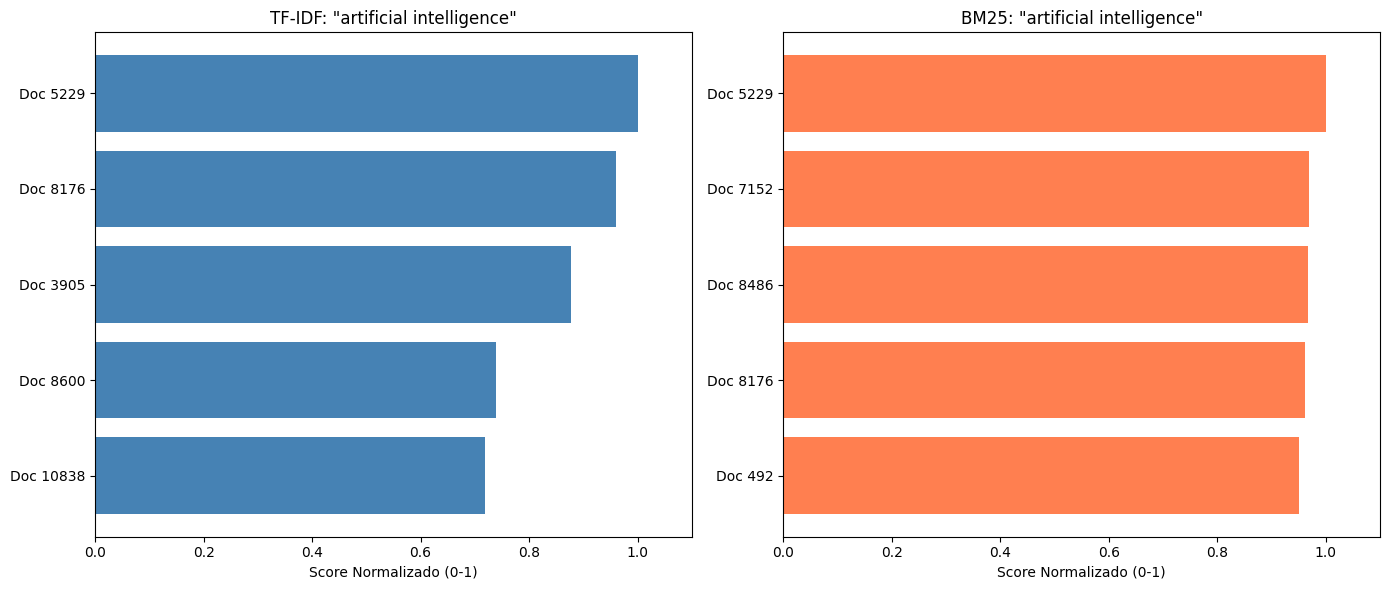

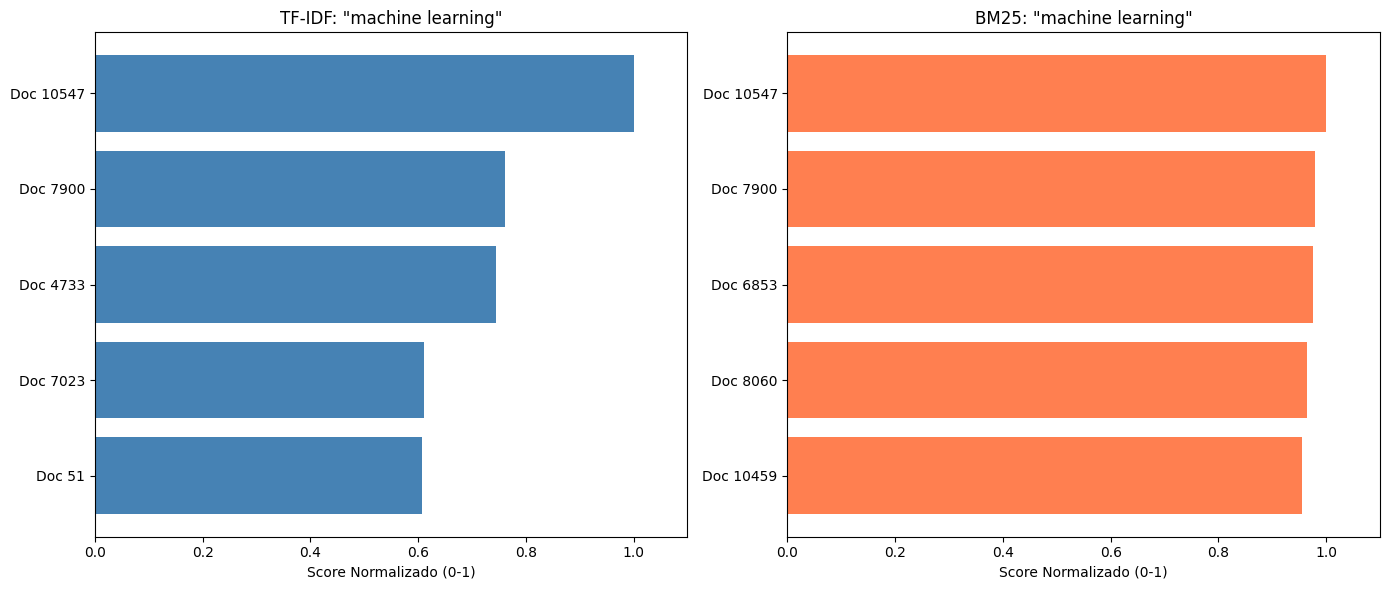

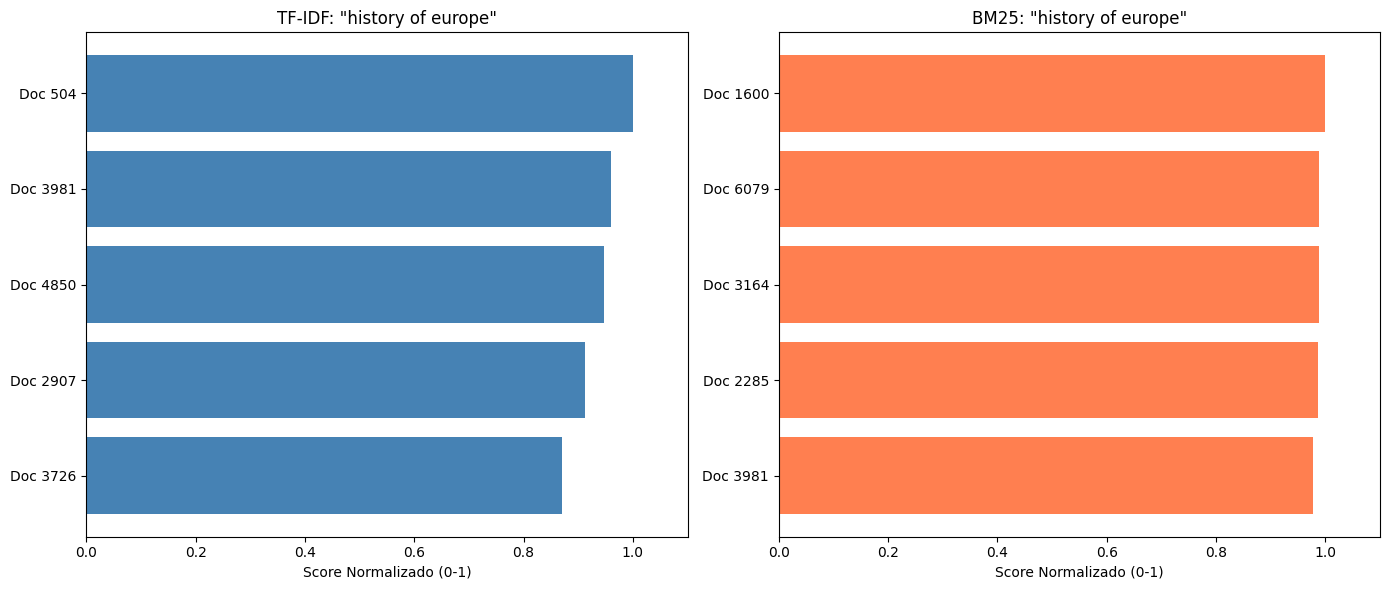

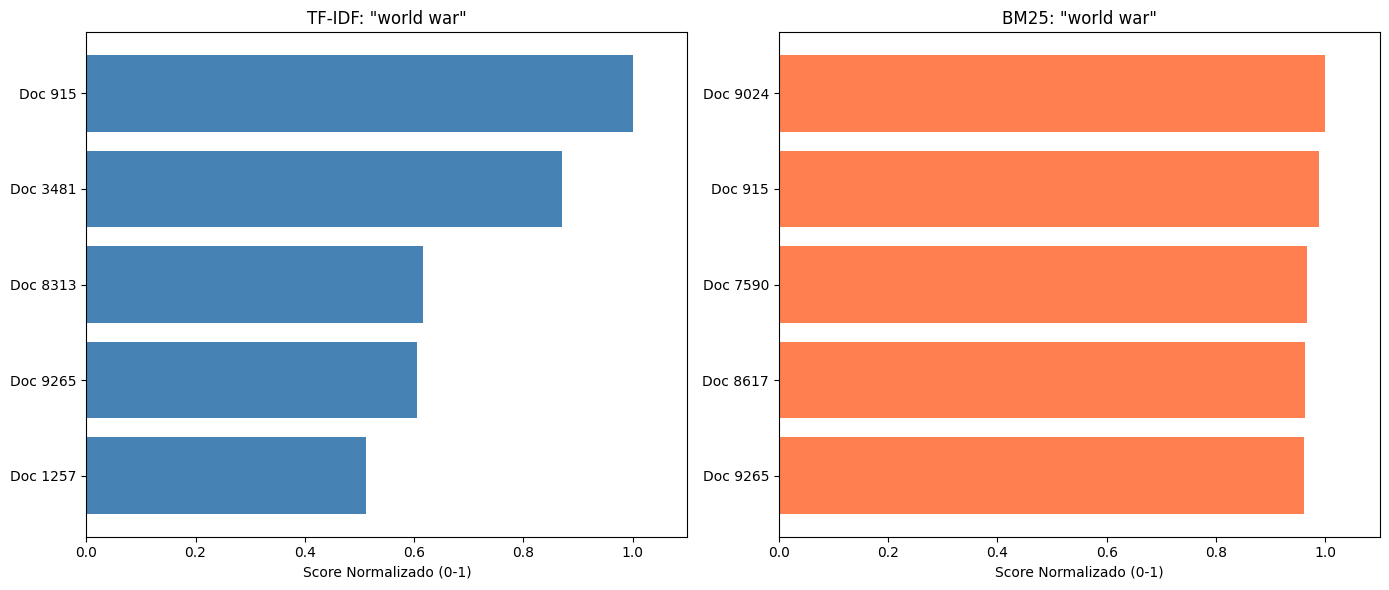

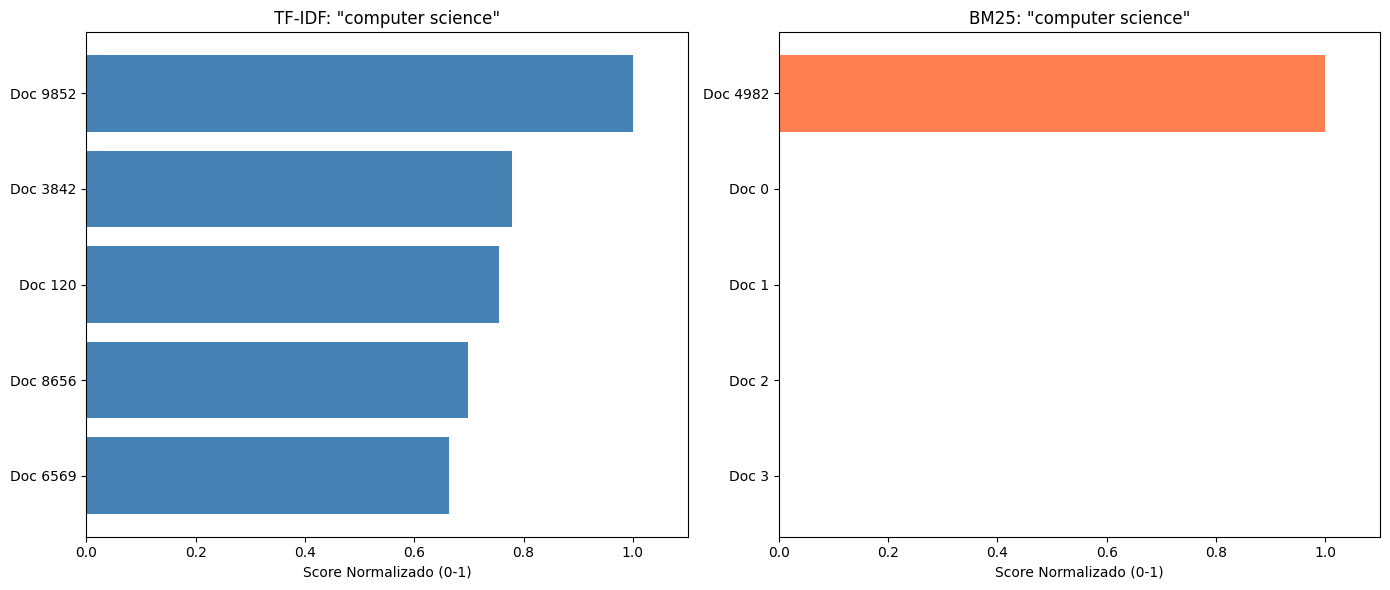

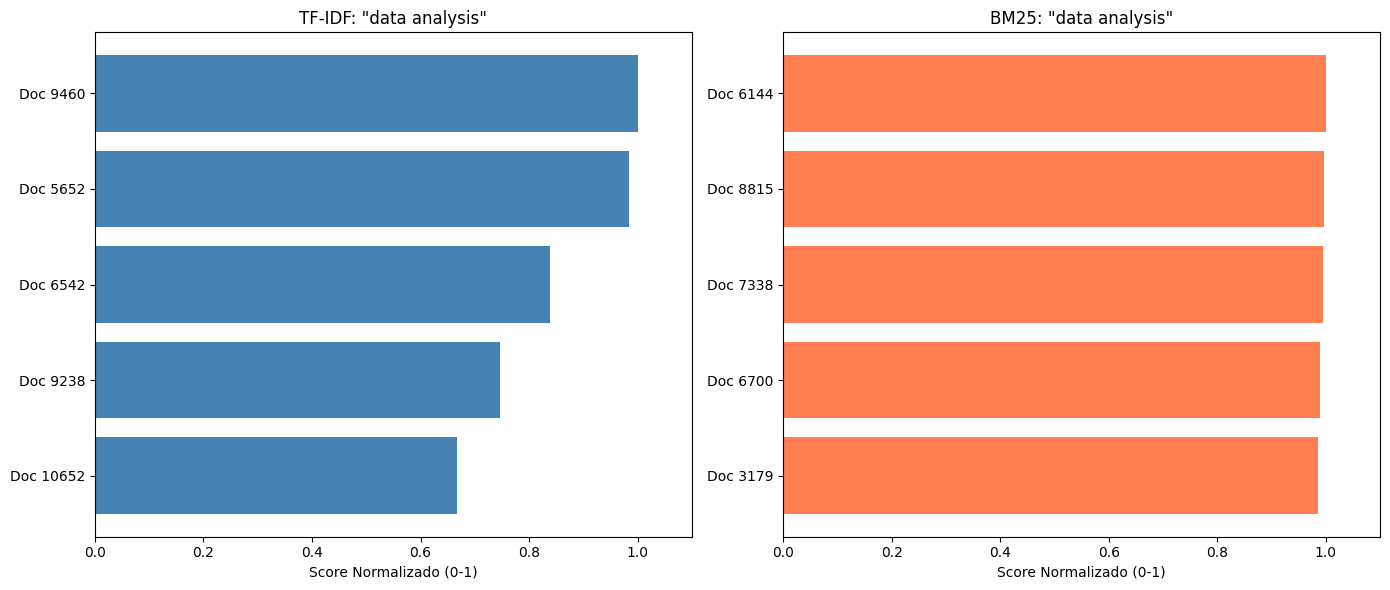

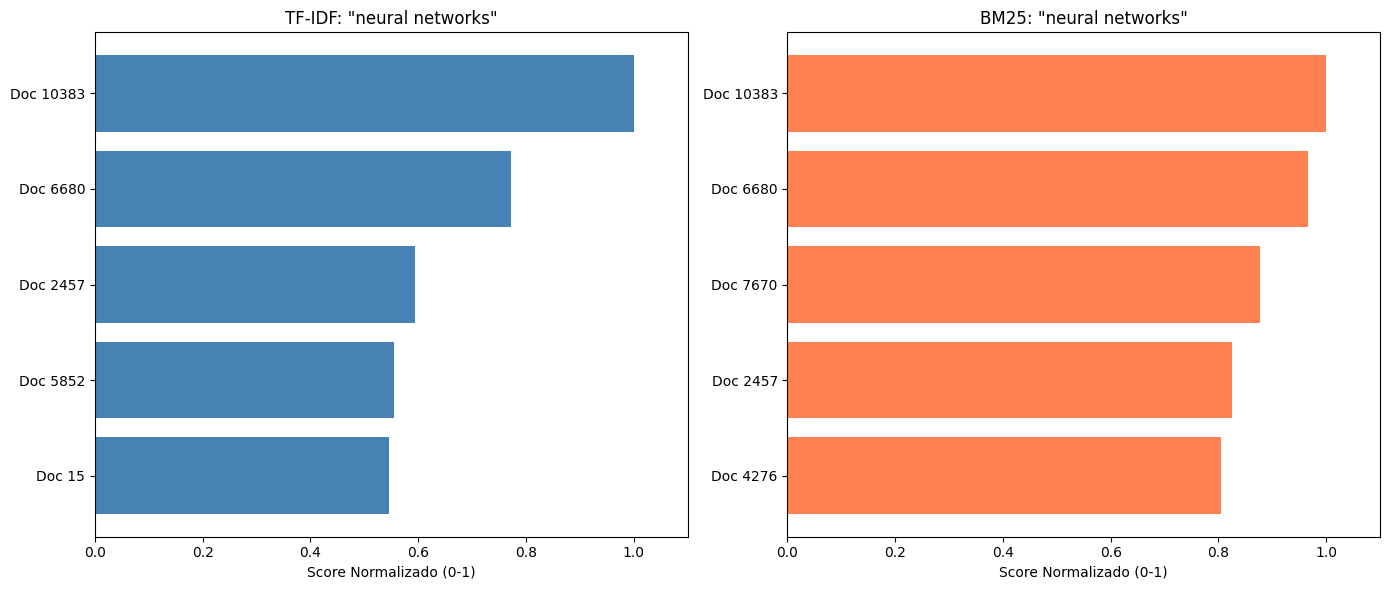

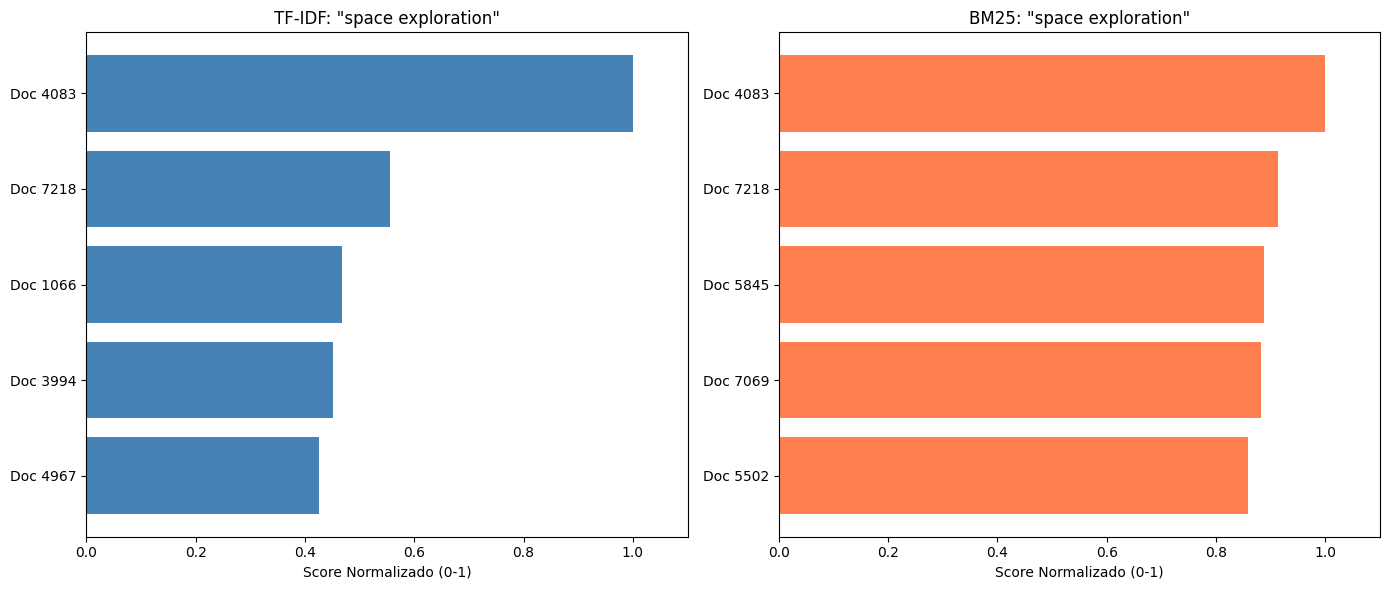

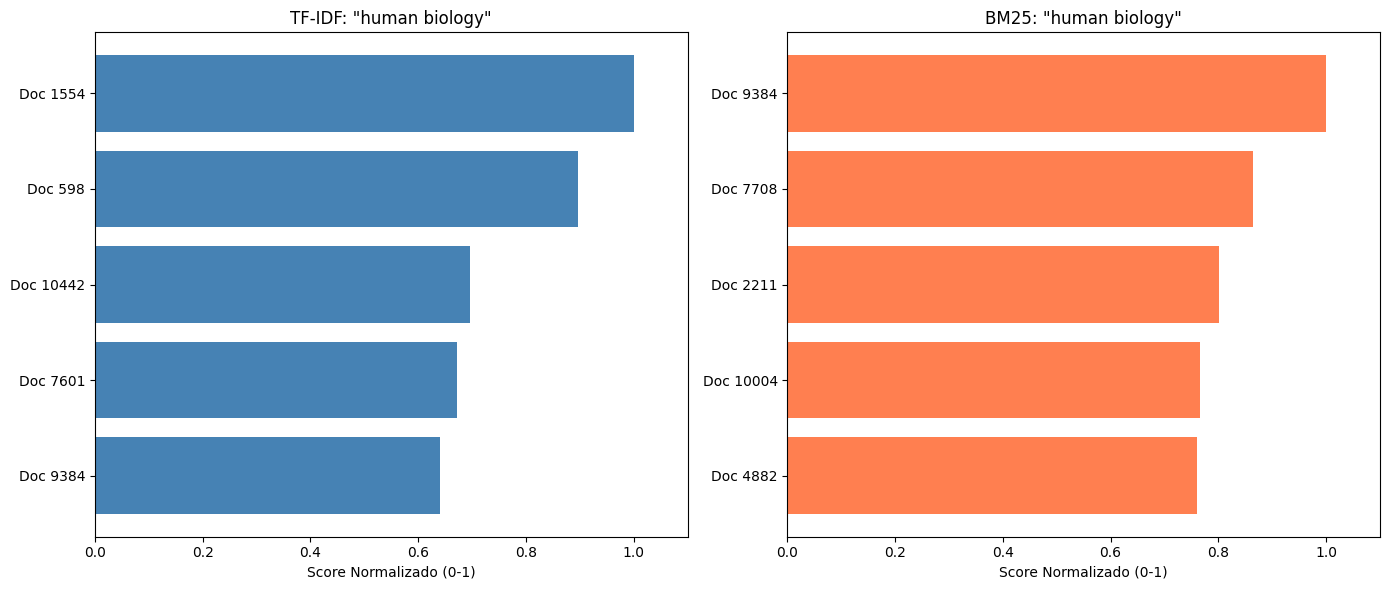

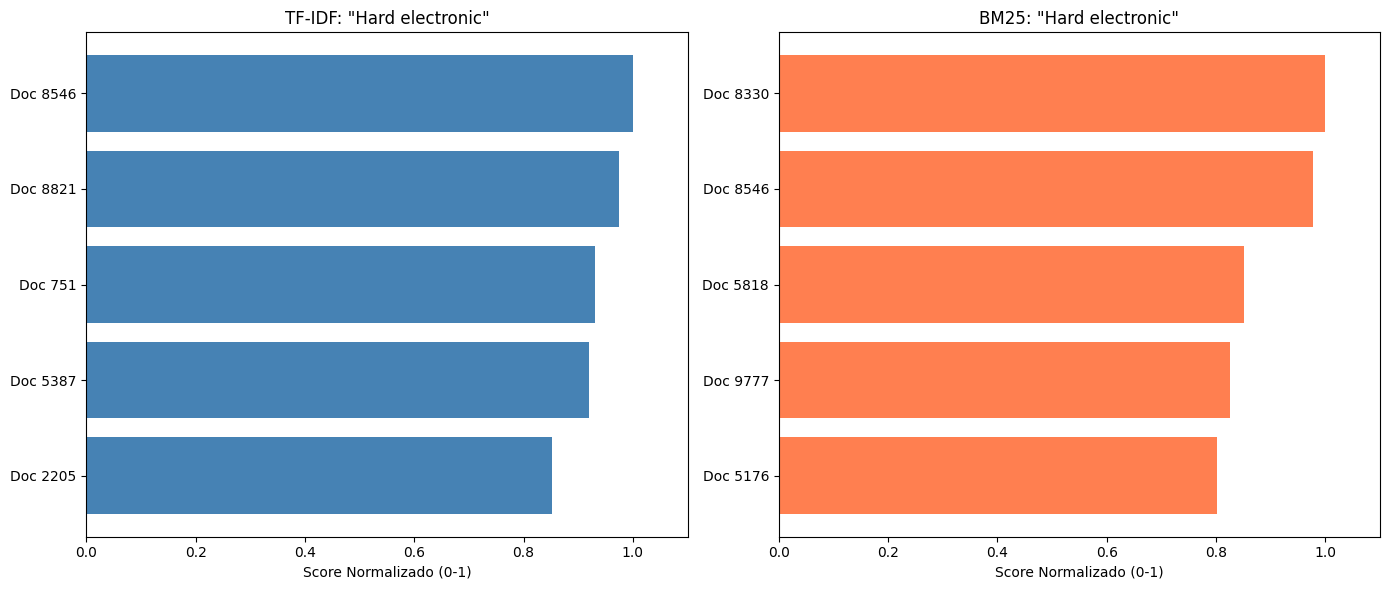

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Función mejorada para comparar TF-IDF y BM25 visualmente
def comparar_modelos_normalizado(query, top_k=5):
    # 1. Obtener resultados de ambos modelos
    results_tfidf = search_tfidf(query, top_k=top_k)
    # Nota: Usamos el nombre de tu función 'buscar_bm25'
    results_bm25 = buscar_bm25(query, top_k)
    
    # 2. Extraer índices y scores (Manejo robusto de diccionarios y tuplas)
    def procesar_resultados(lista):
        indices = []
        scores = []
        for r in lista:
            if isinstance(r, dict):
                # Intentamos las llaves comunes
                idx = r.get('document_id') or r.get('document_index') or r.get('id')
                sc = r.get('score', 0)
            else: # Asumimos tupla (id, score)
                idx, sc = r[0], r[1]
            indices.append(idx)
            scores.append(sc)
        return indices, scores

    tfidf_indices, tfidf_scores_raw = procesar_resultados(results_tfidf)
    bm25_indices, bm25_scores_raw = procesar_resultados(results_bm25)
    
    # 3. NORMALIZACIÓN MÁXIMA
    # Esto permite que ambos gráficos tengan la misma escala de 0 a 1
    def normalize(s_list):
        if not s_list: return []
        m = max(s_list)
        return [s / m if m > 0 else 0 for s in s_list]

    tfidf_scores = normalize(tfidf_scores_raw)
    bm25_scores = normalize(bm25_scores_raw)
    
    # 4. Crear figura
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Gráfico TF-IDF
    axes[0].barh(range(len(tfidf_scores)), tfidf_scores, color='steelblue')
    axes[0].set_yticks(range(len(tfidf_indices)))
    axes[0].set_yticklabels([f"Doc {idx}" for idx in tfidf_indices])
    axes[0].set_xlabel('Score Normalizado (0-1)')
    axes[0].set_xlim(0, 1.1) # Fijamos el eje para comparación justa
    axes[0].set_title(f'TF-IDF: "{query}"')
    axes[0].invert_yaxis()
    
    # Gráfico BM25
    axes[1].barh(range(len(bm25_scores)), bm25_scores, color='coral')
    axes[1].set_yticks(range(len(bm25_indices)))
    axes[1].set_yticklabels([f"Doc {idx}" for idx in bm25_indices])
    axes[1].set_xlabel('Score Normalizado (0-1)')
    axes[1].set_xlim(0, 1.1) # Misma escala que TF-IDF
    axes[1].set_title(f'BM25: "{query}"')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# Ejecución para tus queries
for query in queries:
    comparar_modelos_normalizado(query, top_k=5)

## Comparacion de resultados 

## Para que la compraracion sea eficaz:
se debe normalizar 
